In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [2]:
df = pd.read_csv('../data/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
df.shape

(50000, 2)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.describe().T

,count,unique,top,freq
review,50000,49582,Loved today's show!!! It was a variety and not...,5
sentiment,50000,2,positive,25000


In [6]:
duplicates = df[df.duplicated(subset=['review'], keep=False)]
duplicates.sort_values("review")

,review,sentiment
34058,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
47467,"""Go Fish"" garnered Rose Troche rightly or wron...",negative
29956,"""Three"" is a seriously dumb shipwreck movie. M...",negative
31488,"""Three"" is a seriously dumb shipwreck movie. M...",negative
47527,"""Witchery"" might just be the most incoherent a...",negative
...,...,...
47876,this movie sucks. did anyone notice that the e...,negative
44122,"well, the writing was very sloppy, the directi...",negative
23056,"well, the writing was very sloppy, the directi...",negative
10163,"when I first heard about this movie, I noticed...",positive


In [7]:
df.groupby("review")["sentiment"].nunique().value_counts()

sentiment
1    49582
Name: count, dtype: int64

In [8]:
#Remove Duplicate reviews (redundant data)
df.drop_duplicates(subset=['review'], keep='first', inplace=True)

In [9]:
df.shape

(49582, 2)

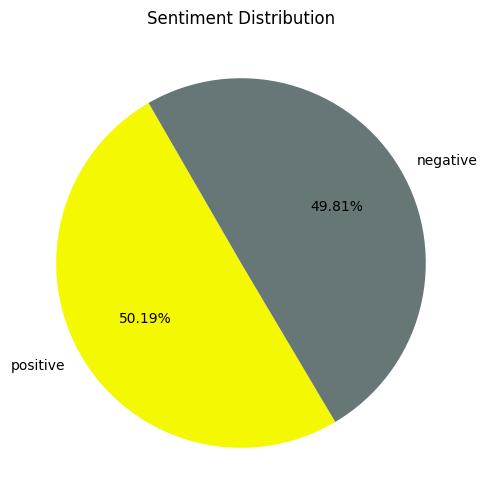

In [10]:
sentiment_counts = df["sentiment"].value_counts()

plt.figure(figsize=(6, 6))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct="%1.2f%%",
    startangle=120,
    colors = ["#f4f800", "#677777"],
)

plt.title("Sentiment Distribution")
plt.show()

In [11]:
sentiment_counts.head()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

In [12]:
for i in range(5): 
    print(f"Review {i+1}:", "\n")
    print(df.iloc[i]["review"], "\n")
    print(f"Sentiment: {df.iloc[i]['sentiment']}", "\n")

Review 1: 

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is du

In [13]:
def no_of_words(text): 
    words  = text.split()
    return len(words)

df["no_of_words"] = df["review"].apply(no_of_words)
df.head()

,review,sentiment,no_of_words
0,One of the other reviewers has mentioned that ...,positive,307
1,A wonderful little production. <br /><br />The...,positive,162
2,I thought this was a wonderful way to spend ti...,positive,166
3,Basically there's a family where a little boy ...,negative,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,230


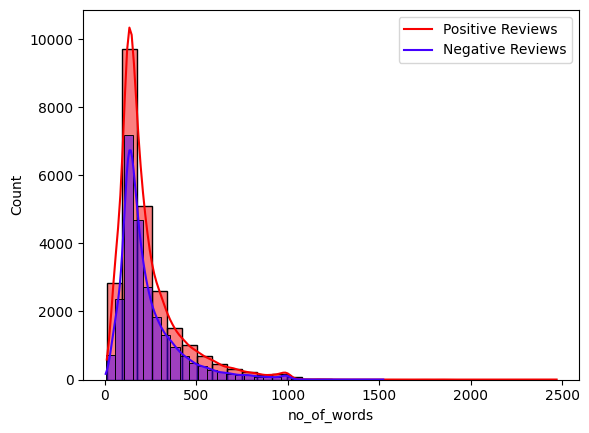

In [14]:
#Histogram of number of words in positive and negative reviews
sns.histplot(df[df["sentiment"]=="positive"]["no_of_words"],color="#f80000", kde=True,bins = 30)
sns.histplot(df[df["sentiment"]=="negative"]["no_of_words"], color="#4400FF", kde=True,bins = 30)
plt.legend(["Positive Reviews", "Negative Reviews"])
plt.show()

In [15]:
#Convert sentiment labels to numerical values for modeling
df["sentiment"].replace({"positive": 1, "negative": 0}, inplace=True)

C:\Users\tanub\AppData\Local\Temp\ipykernel_13400\99305634.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["sentiment"].replace({"positive": 1, "negative": 0}, inplace=True)


In [16]:
df.head()

,review,sentiment,no_of_words
0,One of the other reviewers has mentioned that ...,1,307
1,A wonderful little production. <br /><br />The...,1,162
2,I thought this was a wonderful way to spend ti...,1,166
3,Basically there's a family where a little boy ...,0,138
4,"Petter Mattei's ""Love in the Time of Money"" is...",1,230


In [19]:
def preprocess_text(text):
    # Convert to lowercase
    text = text.lower()
    # Remove punctuation and special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # remove html tags
    text = re.sub(r'<.*?>', '', text)
    return text

In [20]:
df["review"] = df["review"].apply(preprocess_text)

In [21]:
df.head()

,review,sentiment,no_of_words
0,one of the other reviewers has mentioned that ...,1,307
1,a wonderful little production br br the filmin...,1,162
2,i thought this was a wonderful way to spend ti...,1,166
3,basically theres a family where a little boy j...,0,138
4,petter matteis love in the time of money is a ...,1,230
